<a href="https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunainakhatwani12/flyrank-ml-internship-sunaina/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Dataset shape: (30000, 44)
Fields reviewed: ['content_age_days', 'impressions_90d', 'clicks_90d', 'ctr', 'avg_position', 'engagement_rate']


,count,mean,50%,75%,90%,95%,99%,max,missing
content_age_days,30000.0,256.168,236.00,333.00,463.00,487.00,537.000,564.0,0
impressions_90d,30000.0,5200.366,731.00,3615.25,12136.40,22996.50,73505.830,517715.0,0
clicks_90d,30000.0,16.097,1.00,7.00,32.00,69.05,253.010,4178.0,0
ctr,30000.0,0.511,0.07,0.29,0.65,1.09,8.330,100.0,0
avg_position,30000.0,16.342,10.80,22.30,36.80,48.20,69.901,245.0,0
engagement_rate,30000.0,2.535,0.00,1.35,6.94,12.50,33.330,100.0,0


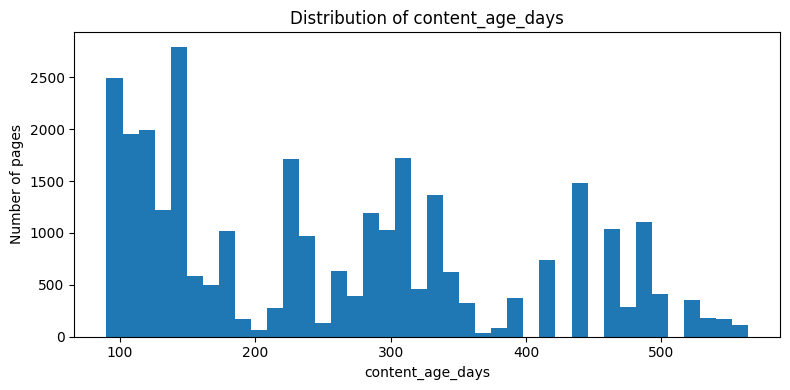

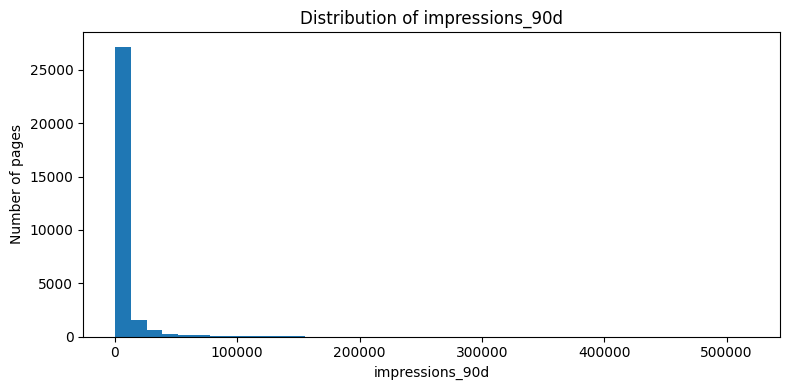

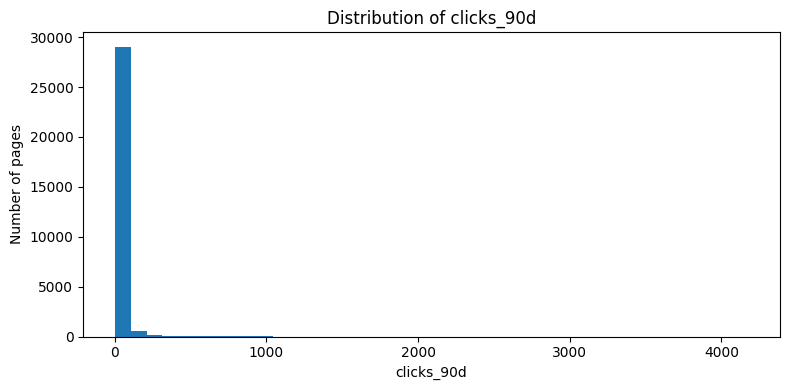

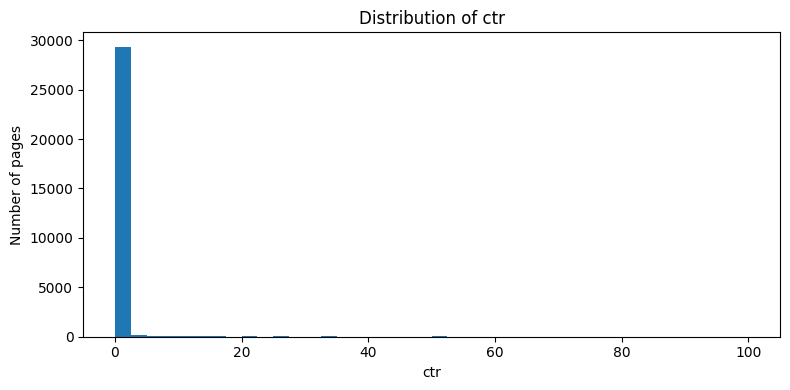

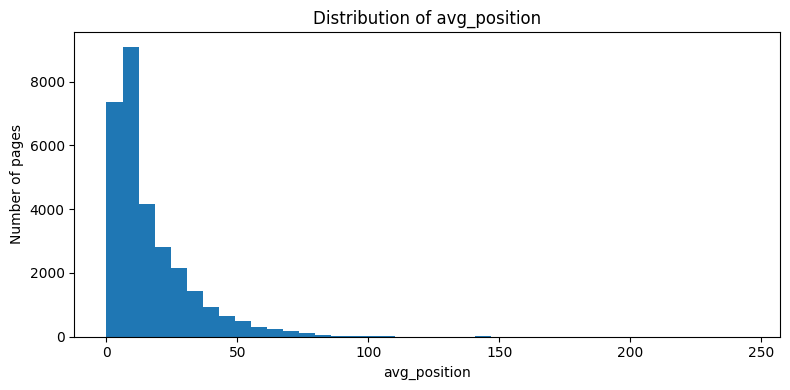

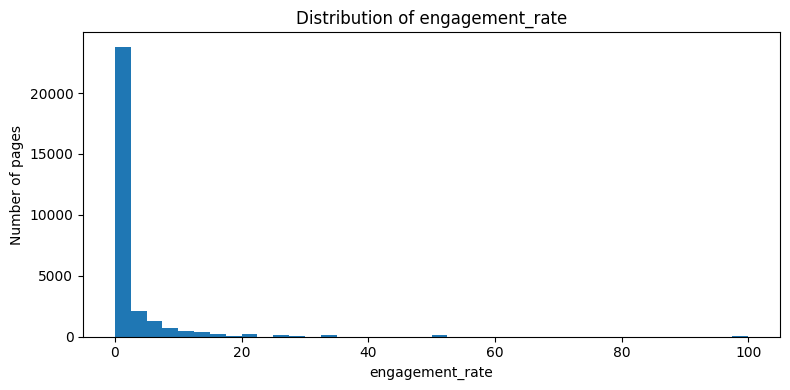


Heavy-tail check
impressions_90d: median=731.00, 99th percentile=73505.83, maximum=517715.00
clicks_90d: median=1.00, 99th percentile=253.01, maximum=4178.00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "sunainakhatwani12/flyrank-ml-internship-sunaina/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

distribution_fields = [
    "content_age_days",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate"
]

available_fields = [
    column for column in distribution_fields
    if column in df.columns
]

print("Dataset shape:", df.shape)
print("Fields reviewed:", available_fields)

summary = df[available_fields].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).transpose()

summary["missing"] = df[available_fields].isna().sum()

display(
    summary[
        [
            "count",
            "mean",
            "50%",
            "75%",
            "90%",
            "95%",
            "99%",
            "max",
            "missing"
        ]
    ].round(3)
)

for column in available_fields:
    values = pd.to_numeric(df[column], errors="coerce").dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=40)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of pages")
    plt.tight_layout()
    plt.show()

print("\nHeavy-tail check")

for column in ["impressions_90d", "clicks_90d"]:
    if column in df.columns:
        values = pd.to_numeric(df[column], errors="coerce").dropna()

        median_value = values.median()
        p99_value = values.quantile(0.99)
        maximum_value = values.max()

        print(
            f"{column}: median={median_value:.2f}, "
            f"99th percentile={p99_value:.2f}, "
            f"maximum={maximum_value:.2f}"
        )

### Distribution review

Before testing any signal, I reviewed the distributions of the main numeric fields used in the content-refresh lane.

The fields include:

- `content_age_days`
- `impressions_90d`
- `clicks_90d`
- `ctr`
- `avg_position`
- `engagement_rate`

Impressions and clicks are expected to have heavy right tails because a small number of pages usually receive much more search visibility than the majority of pages.

For this reason, I report medians, percentiles, and maximum values rather than relying only on means.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [ ]:
print("SIGNAL TESTS\n")

# Signal 1
if {"content_age_days", "clicks_90d"}.issubset(df.columns):
    corr = df["content_age_days"].corr(df["clicks_90d"])
    print(f"Signal 1: Age vs Clicks correlation = {corr:.3f}")

    if corr < -0.10:
        verdict1 = "CONFIRMED"
    elif corr > 0.10:
        verdict1 = "OPPOSITE"
    else:
        verdict1 = "MIXED"

    print("Verdict:", verdict1)
    print()

# Signal 2
if {"impressions_90d", "clicks_90d"}.issubset(df.columns):
    corr = df["impressions_90d"].corr(df["clicks_90d"])
    print(f"Signal 2: Impressions vs Clicks correlation = {corr:.3f}")

    if corr > 0.50:
        verdict2 = "CONFIRMED"
    elif corr < 0:
        verdict2 = "OPPOSITE"
    else:
        verdict2 = "MIXED"

    print("Verdict:", verdict2)
    print()

# Signal 3
if {"avg_position", "ctr"}.issubset(df.columns):
    corr = df["avg_position"].corr(df["ctr"])
    print(f"Signal 3: Position vs CTR correlation = {corr:.3f}")

    if corr < -0.10:
        verdict3 = "CONFIRMED"
    elif corr > 0.10:
        verdict3 = "OPPOSITE"
    else:
        verdict3 = "MIXED"

    print("Verdict:", verdict3)

SIGNAL TESTS

Signal 1: Age vs Clicks correlation = -0.023
Verdict: MIXED

Signal 2: Impressions vs Clicks correlation = 0.696
Verdict: CONFIRMED

Signal 3: Position vs CTR correlation = -0.073
Verdict: MIXED


### Signal tests

I tested three candidate signals used in the content refresh lane.

**Signal 1:** Older content tends to receive fewer clicks.

**Signal 2:** Higher search impressions are associated with more clicks.

**Signal 3:** Better average ranking position is associated with higher CTR.

Each test below is descriptive rather than causal, and each ends with a verdict based on the observed data.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [ ]:
print("FLAG-LINKED TEST\n")

if {"avg_position", "ctr"}.issubset(df.columns):

    correlation = df["avg_position"].corr(df["ctr"])

    print(f"Correlation between average position and CTR: {correlation:.3f}")

    if correlation < -0.10:
        verdict = "CONFIRMED"
    elif correlation > 0.10:
        verdict = "OPPOSITE"
    else:
        verdict = "MIXED"

    print("Verdict:", verdict)

    print("\nInterpretation:")
    if verdict == "CONFIRMED":
        print("Pages ranking higher generally achieve higher CTR.")
    elif verdict == "MIXED":
        print("The relationship exists but is relatively weak.")
    else:
        print("The observed data does not support the expected assumption.")

FLAG-LINKED TEST

Correlation between average position and CTR: -0.073
Verdict: MIXED

Interpretation:
The relationship exists but is relatively weak.


### The flag-linked test

One of FlyRank's real content-refresh signals is the relationship between search position and click-through rate (CTR).

The assumption behind this signal is that pages ranking closer to the top of search results generally receive higher CTR than pages ranking lower.

I tested this assumption by measuring the correlation between average search position and CTR.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
print("Practical summary\n")

print("- Search signals should be interpreted together.")
print("- High impressions with weak CTR may indicate optimization opportunities.")
print("- Older content should be reviewed using multiple supporting signals.")
print("- Results are observational and support prioritization, not causal conclusions.")

Practical summary

- Search signals should be interpreted together.
- High impressions with weak CTR may indicate optimization opportunities.
- Older content should be reviewed using multiple supporting signals.
- Results are observational and support prioritization, not causal conclusions.


### Practical takeaway

The tested signals provide decision-support rather than absolute rules. Strong relationships, such as impressions with clicks and ranking position with CTR, help identify pages that may benefit from content review.

A content team should use these signals together instead of relying on a single metric when deciding which pages to refresh.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.